# Interpretable Machine Learning

----

The machine learning models we have trained in previous workshop have been *black-boxes*. We have no understanding of *why* our models have made their predictions and which of our input features are having the biggest influence on that outcome. It is often useful to understand what a model believes is important, particularly in chemistry, where this information can be used to guide molecular design and build trust in model performance. 

When interrogating model predictions we can look at either *Global* or *local* explanations. *Global* explanations tell us what features are generally important when making a predictions while *local* explanations give information about a specific predictions. We can do both using [SHAP](https://shap.readthedocs.io/en/latest/).

# *SH*apely *A*dditive ex*P*lanations (SHAP)

SHAP aims to explain model predictions by assigning each input feature a contribution score that described its affect on the observed prediction. To do this, a SHAP explainer must learn a *background* prediction value, $\phi_0$, based on the average predictions from the training data:

$$
\phi_0 \approx \frac{1}{N} \sum_{j=1}^{N} f(x_j)
$$

SHAP then explains why the prediction deviates from the baseline:


$$
f(x) = \phi_0 + \sum_{i=1}^{M} \phi_i
$$

where:

* $f(x)$ is the model's prediction for molecule $x$;
* $\phi_0$ is the baseline prediction;
* $M$ is the number of input features;
* $\phi_i$ is the SHAP value for feature $i$.

Positive SHAP values indicate features that push predictions *above* the baseline and negative SHAP values those that push predictions *below* the baseline. 

The difficulty is deciding how much of the deviation is attributed to each input feature. As a simple example, imagine an binary input representation with two features $A$ and $B$. If we only see a high prediction when both are present, how do we decide the contributions of both A and B as the prediction depends on them both? 

This is the purpose of Shapely values. For each feature, we must consider its contribution in combination with all other combinations of features:

$$
\phi_i =
\sum_{S \subseteq F\setminus{i}}
\frac{|S|!(M-|S|-1)!}{M!}
\left[
f(S\cup{i})-f(S)
\right]
$$

where:
* F is the complete set of features
* S is a sub set of features that does not contain feature $i$
* $M$ is the total number of features
* |S| is the number of features in the set

The important part is:
$$
f(S\cup{i})-f(S)
$$

which asks how much does the prediction change when feature $i$ is added. This is calculated for all possible combinations of input features, and is weighted by the term:
$$
\frac{|S|!(M-|S|-1)!}{M!}
$$

When working molecular fingerprints, we can generate SHAP values for each bit in our fingerprint:
$$
\phi = [\phi_1,\phi_2,\ldots,\phi_M]
$$

Essentially giving us a contribution score for each atomic environment in our fingerprint. Remember that fingerprinting is a one-way operation, so there is no way to generate molecular structure directly from a molecular fingerprint. It is possible however to generate bit information when generating the fingerprints that can be used to map each bit to its original substructure. If we keep track of this bit info, we can map the SHAP values back to our original input structure for *local* predictions. 

# Local SHAP Task
----
Use the function below to generate molecular fingerprints from the loaded dataset and train a Random Forest regressor. Notice the addition of the bit_info dictionary, which tracks which atom indices belong to each "on" bit in our fingerprint. We will use this later to map our SHAP explanations back to a molecular stucture. 

```
"""
bit_info : dict
    Mapping from fingerprint bit IDs to the atom environments that generated
    each bit in an RDKit Morgan fingerprint.

    Each dictionary key is a fingerprint bit ID (int). The corresponding value
    is a tuple of ``(atom_idx, radius)`` pairs, where:

    - ``atom_idx`` is the index of the central atom of the environment.
    - ``radius`` is the Morgan fingerprint radius at which that environment
      generated the bit.

    A bit may contain multiple ``(atom_idx, radius)`` entries because multiple
    atom environments can map to the same fingerprint bit.

    Example
    -------
    bit_info = {
        80: ((1, 0),),
        294: ((0, 1), (5, 1)),
        807: ((3, 2),)
    }
"""
```



In [1]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from tdc.single_pred.adme import ADME
import pandas as pd

import numpy as np

def smiles_to_ecfp(smiles, radius=3, nBits=1024):
    mol = Chem.MolFromSmiles(smiles)
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=nBits)
    ao = rdFingerprintGenerator.AdditionalOutput()
    ao.AllocateBitInfoMap() # generates bit_info map
    ecfp = np.array(gen.GetFingerprint(mol, additionalOutput=ao))
    bit_info = ao.GetBitInfoMap()

    return ecfp, bit_info, mol

solubility_data = ADME('Solubility_AqSolDB')
solubility_split = solubility_data.get_split() # use predefined splits 

train_df = pd.concat([solubility_split["train"], solubility_split["valid"] ])
test_df = solubility_split["test"]

# convert dataframes to np arrays 
train_smiles = train_df["Drug"].to_numpy()
train_solubility = train_df["Y"].to_numpy()

test_smiles = test_df["Drug"].to_numpy()
test_solubility = test_df["Y"].to_numpy()


bits = [smiles_to_ecfp(x) for x in train_smiles]
fps = np.array([x[0] for x in bits]) 
bi = np.array([x[1] for x in bits])
mols = np.array([x[2] for x in bits])

Found local copy...
Loading...
Done!
[12:19:15] WARNING: not removing hydrogen atom without neighbors
[12:19:15] WARNING: not removing hydrogen atom without neighbors
[12:19:15] WARNING: not removing hydrogen atom without neighbors
[12:19:16] WARNING: not removing hydrogen atom without neighbors
[12:19:16] WARNING: not removing hydrogen atom without neighbors
[12:19:16] WARNING: not removing hydrogen atom without neighbors
[12:19:17] WARNING: not removing hydrogen atom without neighbors
[12:19:17] WARNING: not removing hydrogen atom without neighbors
[12:19:17] WARNING: not removing hydrogen atom without neighbors
[12:19:17] WARNING: not removing hydrogen atom without neighbors
[12:19:17] WARNING: not removing hydrogen atom without neighbors
[12:19:17] WARNING: not removing hydrogen atom without neighbors
[12:19:17] WARNING: not removing hydrogen atom without neighbors
[12:19:17] WARNING: not removing hydrogen atom without neighbors
[12:19:17] WARNING: not removing hydrogen atom withou

In [2]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(max_depth=60)
print("traigin model")
model.fit(fps, train_solubility)



traigin model


RandomForestRegressor(max_depth=60)

Now write code to explain a prediction using SHAP. You will need to:
* Initialise the explainer using `shap.TreeExplainer(model)`
* Convert the test set into ECFPs using the new function
* Get shap values for predictions with `shap_values = explainer.shap_values(test_fps[[0]]) # any int you want`
* Select one molecule's SHAP values `mol_values = shap_values[0] # select the first entry`
* Convert those values into a dictionary that assigns each score to a bit number `shap_dict = {i: float(mol_values[i]) for i in range(len(mol_values))}`

In [3]:
test_bits = [smiles_to_ecfp(x) for x in test_smiles]
test_fps = np.array([x[0] for x in test_bits])
test_bit_info = [x[1] for x in test_bits]
test_mols = [x[2] for x in test_bits]

[12:22:38] WARNING: not removing hydrogen atom without neighbors
[12:22:39] WARNING: not removing hydrogen atom without neighbors
[12:22:39] WARNING: not removing hydrogen atom without neighbors
[12:22:39] WARNING: not removing hydrogen atom without neighbors
[12:22:39] WARNING: not removing hydrogen atom without neighbors
[12:22:40] WARNING: not removing hydrogen atom without neighbors
[12:22:40] WARNING: not removing hydrogen atom without neighbors
[12:22:40] WARNING: not removing hydrogen atom without neighbors
[12:22:40] WARNING: not removing hydrogen atom without neighbors
[12:22:40] WARNING: not removing hydrogen atom without neighbors
[12:22:40] WARNING: not removing hydrogen atom without neighbors
[12:22:40] WARNING: not removing hydrogen atom without neighbors
[12:22:40] WARNING: not removing hydrogen atom without neighbors
[12:22:40] WARNING: not removing hydrogen atom without neighbors
[12:22:40] WARNING: not removing hydrogen atom without neighbors
[12:22:41] WARNING: not r

In [4]:
import shap

print("training shap")
explainer = shap.TreeExplainer(model)

training shap


In [5]:
print(" getting values")
molecule = 50

small_test_fp = test_fps[[molecule]] 
small_test_bi = test_bit_info[molecule]
small_test_mol = test_mols[molecule]

shap_values = explainer.shap_values(small_test_fp) # explain all fps

mol_values = shap_values[0]

shap_dict = {i: float(mol_values[i]) for i in range(len(mol_values))}


 getting values


Now we have a dictionary detailing the SHAP values arranged by bit number for all bits in our molecular fingerprint. We can assign these values as atom weights to our molecule and overlay a heat map on the molecular structure to show which parts of the molecule are influencing the prediction. 

To convert our SHAP values into atom weights we need to:
1. Initialise a numpy array to track our atom weights
2. Loop through each bit: environment pair in our molecule's bit_info dictionary
3. Extract the SHAP score for each bit
4. Loop through each (atom_idx, radius) pair in the environment
5. Add the SHAP score to each atom in the atom

Use the function below to convert the SHAP scores for you selected molecule to atom_weights 
 

In [6]:
def shap_scores_to_atom_weights(rdmol, bit_info, shap_scores):
    natoms = rdmol.GetNumAtoms()
    atom_weights = np.zeros((natoms,), dtype=np.float64)
    
    for bit_id, envs in bit_info.items():
        shap_score = shap_scores[bit_id]
        for atom_idx, radius in envs:
            atom_weights[atom_idx] += float(shap_score)
    return atom_weights.tolist()

Now we can draw our molecule and visualise the atom_weights as a heatmap overlaid on the chemical structure. 

Use the function below to visualise your molecule using the atom weights you have just generated. 

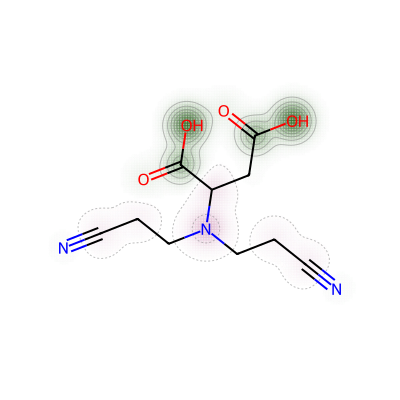

In [7]:
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import SimilarityMaps
from IPython.display import Image, display


def draw_molecule_with_heatmap(mol, atom_weights, size=(400, 400), legend=None):
    """
    Draw and display a molecule with a similarity-map heatmap based on atom weights.
    """
    AllChem.Compute2DCoords(mol)

    drawer = Draw.MolDraw2DCairo(*size)

    SimilarityMaps.GetSimilarityMapFromWeights(
        mol,
        atom_weights,
        draw2d=drawer,
        legend=legend,
        colormap="coolwarm"
    )

    drawer.FinishDrawing()

    display(Image(data=drawer.GetDrawingText()))

atom_weights = shap_scores_to_atom_weights(small_test_mol, small_test_bi, shap_dict)
draw_molecule_with_heatmap(small_test_mol, atom_weights, size=(400, 400))

Now we can exactly which molecular features are influencing our models prediction. Try running the explanations on different molecules and answer the following questions:
* What molecular features influence predictions of solubility? 
* Do these features make chemical sense?

----
# Global Explanations


These explanations are useful for understanding *why* a model has made a prediction for one molecule. While viewing the explanations for multiple predictions can help to build a broad picture of what the model considers important, it is instead more useful to investigate global explanations. We can use global SHAP values to find which bits have the highest influence across the whole dataset, then look through our training set to find examples of those environments. 

To investigate global explanations, we must first generate shap values for all molecular fingerprints. We will be focussing on explaining the training set in this section. 

To speed up the compute time, we will be investigating a sub-set of 200 training molecules.

First we generate the SHAP values for our 200 molecules. This can take a few minutes...

In [61]:
train_shap = explainer(fps[200:400])

Once we have these, we can find the bits which have the highest absolute influence on the solubility prediction

In [65]:
mean_abs_shap = np.abs(train_shap.values).mean(axis=0)

top_bits = np.argsort(mean_abs_shap)[::-1][:20]

for bit in top_bits:
    print(bit, mean_abs_shap[bit])

356 0.29379385832129035
849 0.1972385547587086
887 0.17974307509029241
807 0.15863306498599455
119 0.1387900408579651
784 0.13268858194631908
561 0.1066349925095622
875 0.0936604870605969
222 0.08132155981017992
114 0.07287644812023192
189 0.05929737655405052
301 0.05524132865558537
695 0.05169546675875823
333 0.05156002837250866
1011 0.05149862128596744
175 0.04994751790989487
147 0.04875448535254641
366 0.04873262774377887
842 0.04674653150835642
33 0.045585971670690034


It can be helpful to visualise this information. The SHAP library provides some useful plots. 

#### Beeswarm plot

The Beeswarm plot shows how the top features affect predictions across the dataset. Each dot shows an instance of that feature and its associated SHAP value. The resultant density gives both an insight into the dataset and that features affect on the predictions.

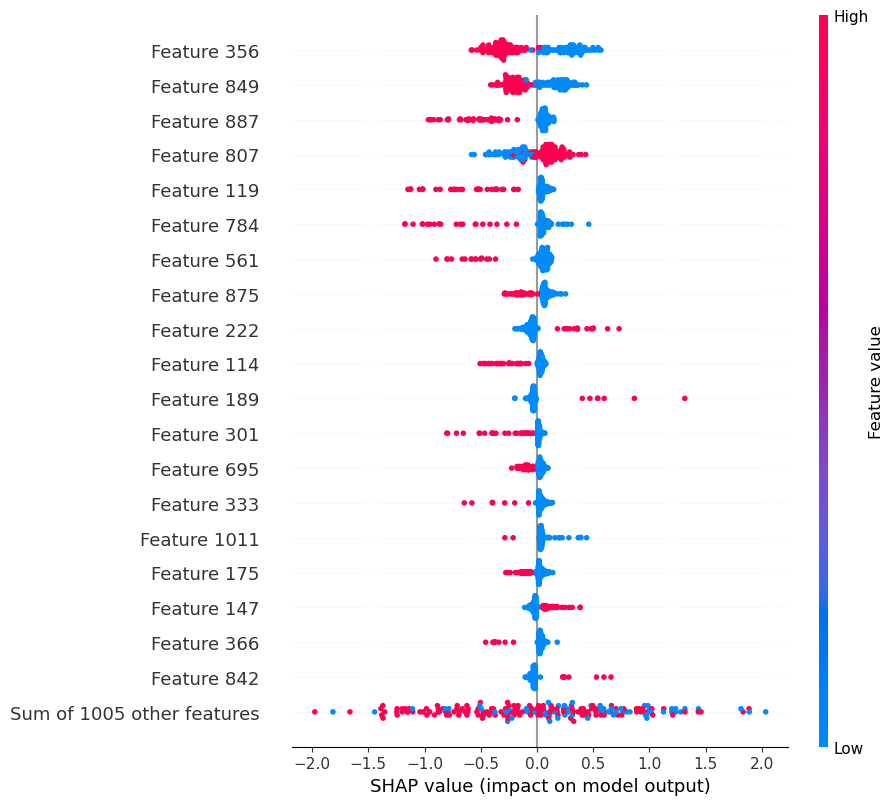

In [66]:
shap.plots.beeswarm(train_shap, max_display=20)

As our input features are binary fingerprints, each feature can be present (1) or not (0). This beeswarm plot shows us a clear separation between high and low feature values which correspond to the binary nature of the input features. 

So, what chemical structure do these top bits correspond to? To find out, we need to search through our training molecules for fingerprints that contain this bit and visualise the atomic environment. 

The function below searches a list of fingerprints and returns those with a 1 at the corresponding bit_index. Use this function to search 



In [52]:
def find_bit_fps(bit_index, fingerprints, bit_infos, rdmols):
    indices = np.flatnonzero(fingerprints[:, bit_index])
    
    matching_fps = fps[indices]
    matching_bit_infos = bit_infos[indices]
    matching_rdmols = rdmols[indices]
    
    return indices, matching_fps, matching_bit_infos, matching_rdmols


def get_bit_atoms(mol, bit_info, bit_index):
    highlight_atoms = set()
    highlight_bonds = set()

    for center_atom, radius in bit_info[bit_index]:
        highlight_atoms.add(center_atom)

        if radius == 0:
            continue

        bond_ids = Chem.FindAtomEnvironmentOfRadiusN(
            mol,
            radius,
            center_atom
        )

        highlight_bonds.update(bond_ids)

        for bond_id in bond_ids:
            bond = mol.GetBondWithIdx(bond_id)
            highlight_atoms.add(bond.GetBeginAtomIdx())
            highlight_atoms.add(bond.GetEndAtomIdx())

    return sorted(highlight_atoms), sorted(highlight_bonds)


def draw_bit_grid(bit_index, fingerprints, bit_infos, rdmols, n=6):

    indices, _, matching_bit_infos, matching_rdmols = find_bit_fps(
        bit_index,
        fingerprints,
        bit_infos,
        rdmols
    )

    for idx, mol, bit_info in zip(
        indices[:n],
        matching_rdmols[:n],
        matching_bit_infos[:n]
    ):
        highlight_atoms, highlight_bonds = get_bit_atoms(
            mol,
            bit_info,
            bit_index
        )

        img = Draw.MolToImage(
            mol,
            highlightAtoms=highlight_atoms,
            highlightBonds=highlight_bonds,
            legend=f"Mol {idx} — Bit {bit_index}"
        )

        display(img)


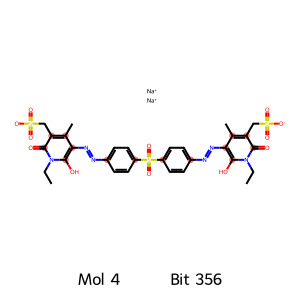

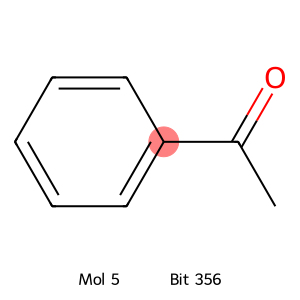

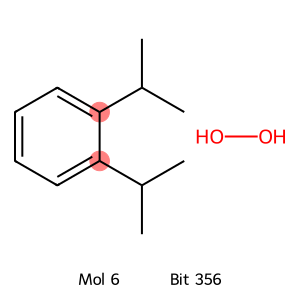

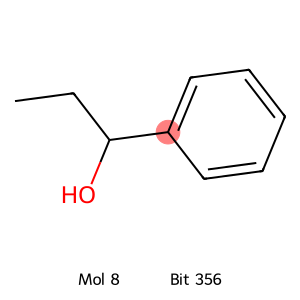

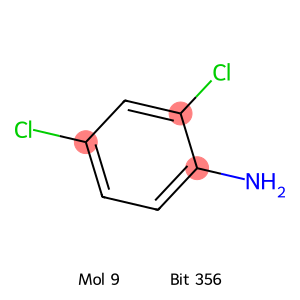

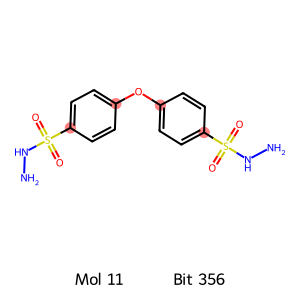

In [67]:
train_fps = fps[200:400]
train_bit_info = bi[200:400]
train_mols = mols[200:400]

draw_bit_grid(356, train_fps, train_bit_info, train_mols)


Use the above code to answer the following questions:
* What do these global explanations tell you about the model?
* Do these conclusions match the local ones?
* How do the important bits differ for different segments of the training set?

----
# Per-molecule heatmaps

The SHAP library also allows us to plot heatmaps to show the SHAP values for each feature of our fignerprint for each molecule. This can be visually overwhelming, so we will only show the first 20 features.

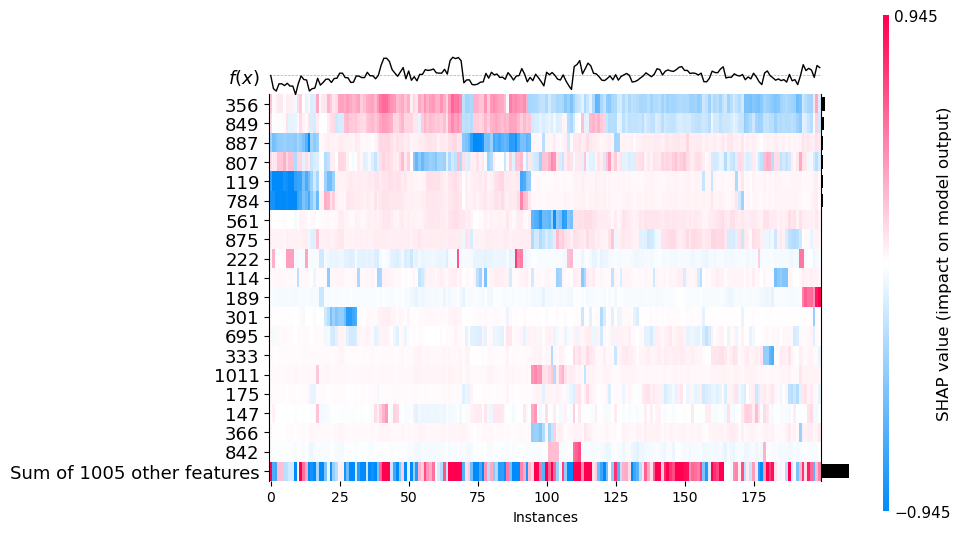

<Axes: xlabel='Instances'>

In [76]:
feature_names = [f"{i}" for i in range(fps.shape[1])]
train_shap.feature_names = feature_names

shap.plots.heatmap(train_shap, max_display=20)